# 数据预处理

本 Notebook 演示 PyTorch 图像数据预处理的完整流程，包括图像读取、张量转换、均值/标准差计算以及逐通道归一化。

## 一、图像读取与张量转换

使用 `matplotlib.pyplot.imread` 读取本地图像文件，并通过 `torch.from_numpy` 将其转换为 PyTorch 张量，为后续深度学习处理做准备。

img_tensor 的 shape 是：torch.Size([1024, 1536, 3])


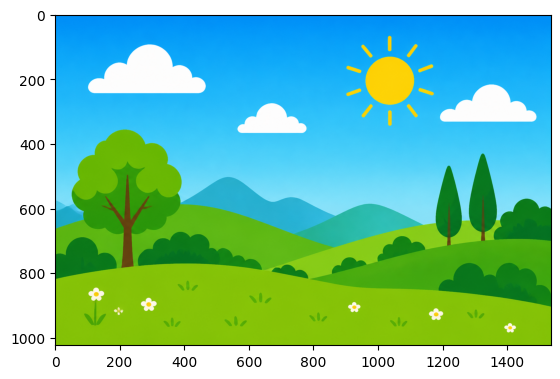

In [2]:
import matplotlib.pyplot as plt  # 导入 matplotlib 绘图库的 pyplot 子模块，别名 plt，提供图像读取（imread）与可视化（imshow）等功能

# -------------------------------------------------------
# plt.imread 接口说明
#   功能  ：从磁盘读取图像文件，返回 numpy.ndarray
#   参数  ：fname (str) — 图像文件路径，支持 PNG、JPG 等格式
#   返回值：numpy.ndarray
#           · PNG 图像 → float32，像素值域 [0.0, 1.0]
#           · JPG 图像 → uint8，像素值域 [0, 255]
#           · shape 通常为 (H, W, 3) 表示 RGB，或 (H, W, 4) 表示 RGBA
# -------------------------------------------------------
img = plt.imread('demo_image.png')  # 读取示例图片，img 为 numpy.ndarray，shape=(H, W, C)

import torch  # 导入 PyTorch 深度学习框架，提供 Tensor 数据结构、自动微分及 GPU 加速等核心能力

# -------------------------------------------------------
# torch.from_numpy 接口说明
#   功能  ：将 numpy.ndarray 原地转换为 torch.Tensor，两者共享同一块内存（不发生数据拷贝）
#   参数  ：ndarray (numpy.ndarray) — 待转换的数组
#   返回值：torch.Tensor
#           · dtype 与输入 numpy 数组保持一致（float32 → torch.float32）
#           · shape 与输入完全相同
# -------------------------------------------------------
img_tensor = torch.from_numpy(img)  # 将 numpy 数组 img 转换为 PyTorch 张量，shape=(H, W, C)

# -------------------------------------------------------
# plt.imshow 接口说明
#   功能  ：在当前坐标轴内渲染并显示图像
#   参数  ：X (array-like) — 图像数据，形状须为 (H, W, 3) 或 (H, W, 4)，通道维在最后
#   注意  ：此时 img_tensor 仍为 (H, W, C) 格式（"channel-last"），与 imshow 要求一致
# -------------------------------------------------------
plt.imshow(img_tensor);  # 显示原始图像，输入 shape=(H, W, C)，通道在最后一维；末尾 ; 抑制 AxesImage 返回值输出

# print 内置函数 + f-string 格式化
# .shape 属性：返回 torch.Size 对象，描述各维度大小，例如 torch.Size([480, 640, 3])
print(f"img_tensor 的 shape 是：{img_tensor.shape}")  # 打印张量形状，通常为 torch.Size([H, W, 3])


## 二、图像归一化处理

将图像张量的通道格式由 `(H, W, C)` 转换为 PyTorch 标准的 `(C, H, W)`，计算每个通道的均值与标准差，然后使用 `torchvision.transforms.Normalize` 执行逐通道标准化，并可视化归一化结果。

R 通道 -> 均值: 0.311334, 标准差: 0.250475
G 通道 -> 均值: 0.722328, 标准差: 0.119752
B 通道 -> 均值: 0.560132, 标准差: 0.453955


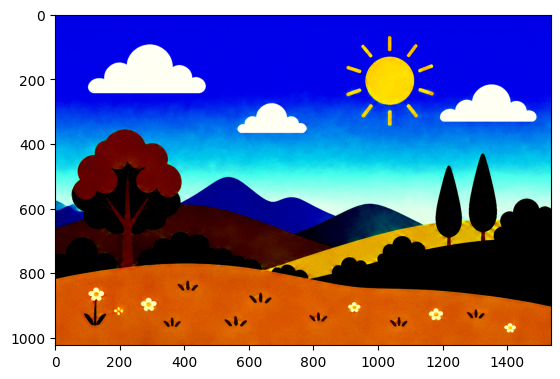

In [3]:
from torchvision.transforms import Normalize  # 从 torchvision.transforms 导入 Normalize 变换类，用于对张量图像进行逐通道标准化（zero-mean unit-variance）

# -------------------------------------------------------
# torch.Tensor.permute 接口说明
#   功能  ：按指定顺序重新排列张量的各个维度（返回视图，不拷贝数据）
#   参数  ：dims (tuple[int]) — 新维度顺序，(2, 0, 1) 表示：原第2维→新第0维，原第0维→新第1维，原第1维→新第2维
#   输入  ：img_tensor，shape=(H, W, C)，即 "channel-last" 格式
#   返回值：torch.Tensor，shape=(C, H, W)，即 "channel-first" 格式（PyTorch 标准输入格式）
# -------------------------------------------------------
img_c_first = img_tensor.permute(2, 0, 1)  # 将 [H, W, C] 转置为 [C, H, W]，符合 PyTorch 通道优先规范


def cal_mean_std(img):
    """
    计算图像每个通道的均值与标准差，用于后续归一化变换。

    参数:
        img (torch.Tensor): 形状为 [C, H, W] 的图像张量
                            C — 通道数（RGB 图像为 3）
                            H — 图像高度（像素行数）
                            W — 图像宽度（像素列数）

    返回:
        mean (torch.Tensor): 形状为 [C]，每个通道所有像素的均值（float32）
        std  (torch.Tensor): 形状为 [C]，每个通道所有像素的标准差（无偏估计，分母为 N-1，float32）
    """
    # torch.Tensor.mean(dim) 接口：沿指定维度进行均值归约
    # dim=(1, 2) — 同时对 H（dim=1）和 W（dim=2）做归约，C 维（dim=0）保留
    # 输入 shape=[C, H, W]，输出 shape=[C]，每个元素是对应通道 H×W 个像素的算术平均值
    mean = img.mean(dim=(1, 2))  # 返回 torch.Tensor，shape=[C]，dtype=float32

    # torch.Tensor.std(dim) 接口：沿指定维度计算标准差
    # dim=(1, 2) — 同时对 H 和 W 做归约；unbiased=True（默认），分母为 N-1（无偏估计）
    # 输入 shape=[C, H, W]，输出 shape=[C]，每个元素是对应通道的像素标准差
    std = img.std(dim=(1, 2))  # 返回 torch.Tensor，shape=[C]，dtype=float32

    return mean, std  # 返回二元组 (均值向量 Tensor[C], 标准差向量 Tensor[C])


mean, std = cal_mean_std(img_c_first)  # 调用函数，计算 img_c_first 各通道的均值与标准差，shape 均为 [C]

channel_names = ["R", "G", "B"]  # 通道名称列表（字符串），与 RGB 图像的通道顺序一一对应
# zip 内置函数：将多个可迭代对象打包为元组迭代器，使 channel_names、mean 列表、std 列表同步遍历
# .tolist() 方法：将 shape=[C] 的 Tensor 转换为 Python float 列表，便于 f-string 格式化输出
for ch, m, s in zip(channel_names, mean.tolist(), std.tolist()):
    # f-string 格式化：{m:.6f} 与 {s:.6f} 分别将均值和标准差保留 6 位小数输出
    print(f"{ch} 通道 -> 均值: {m:.6f}, 标准差: {s:.6f}")  # 逐通道打印归一化参数，便于检验

# -------------------------------------------------------
# torchvision.transforms.Normalize 接口说明
#   功能  ：对 shape=(C, H, W) 的 float Tensor 执行逐通道标准化
#           公式：output[c] = (input[c] - mean[c]) / std[c]
#   参数  ：mean (sequence) — 各通道均值序列（长度=C）
#           std  (sequence) — 各通道标准差序列（长度=C）
#   返回值：与输入同 shape 的 torch.Tensor，各通道均值趋近 0、方差趋近 1
# -------------------------------------------------------
norm = Normalize(mean, std)  # 构造归一化变换对象，mean/std 均为 shape=[C] 的 Tensor
img_norm = norm(img_c_first)  # 对 img_c_first 执行逐通道标准化，输入/输出 shape 均为 [C, H, W]

# torch.Tensor.permute 接口（同上）：将 [C, H, W] 还原为 [H, W, C]
# 满足 plt.imshow "channel-last" 要求，参数 (1, 2, 0) 意为：原第1维→新第0维，原第2维→新第1维，原第0维→新第2维
img_norm_show = img_norm.permute(1, 2, 0)  # 输出 shape=[H, W, C]，供 plt.imshow 可视化

# -------------------------------------------------------
# 归一化后像素值域变为约 [-3, +3]（以 0 为中心），超出 [0, 1] 会触发 imshow 的 Clipping 警告。
# 这是正常的数学结果：Normalize 目的是让网络训练稳定，归一化图像本不适合直接可视化。
# torch.clamp 接口说明
#   功能  ：将张量所有元素截断到 [min, max] 范围（超出则置边界值）
#   参数  ：input (Tensor) — 输入张量；min (float) — 下界；max (float) — 上界
#   返回值：与输入同 shape 的 Tensor，仅用于可视化，不影响 img_norm 本身
# -------------------------------------------------------
img_norm_clamp = torch.clamp(img_norm_show, 0.0, 1.0)  # 截断到 [0, 1]，仅用于显示，消除 Clipping 警告

plt.imshow(img_norm_clamp);  # 显示截断后的归一化图像，末尾 ; 抑制 AxesImage 返回值输出
